## Search for NISAR data in Pacific Northwest 

Pacific northwest polygon:
https://geopub.epa.gov/ArcGIS/rest/services/icr/icrmap/MapServer/46

We'll use this polygon to search for NISAR data in the Pacific Northwest.

Refer to https://nisar-docs.asf.alaska.edu for documentation.


In [1]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import asf_search

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
#url = "https://geopub.epa.gov/ArcGIS/rest/services/icr/icrmap/MapServer/46/query?where=1%3D1&outFields=*&f=geojson"
#aoi = gpd.read_file(url)

In [3]:
#aoi.count_coordinates()

In [4]:
#aoi.simplify(0.01).count_coordinates()

In [5]:
#aoi.to_file("cascadia.geojson", driver="GeoJSON")
#aoi.simplify(0.01).to_file("cascadia_simplified.geojson", driver="GeoJSON")

In [6]:
aoi = gpd.read_file("cascadia_simplified.geojson")

In [7]:
aoi.simplify(0.01).explore()

In [8]:
search_wkt = aoi.simplify(0.1).union_all().wkt
search_wkt

'POLYGON ((-122.0581387830155 42.005511658352255, -117.36283812743987 41.98855739102594, -117.2905163790863 41.75952189871251, -116.80173269608288 41.63137880195333, -116.61692649679651 41.37779057457439, -116.35687855735921 41.387691391451185, -116.20696876994391 41.12777067830098, -115.98218611129458 41.24104642258351, -115.97697812394334 41.599925218689755, -115.73290494945805 41.495869541680996, -115.62217287628596 41.617390202263415, -115.40786768741026 41.413150923383796, -115.41994337326203 41.77978706107834, -114.93489449893441 41.43244532465802, -114.68242605877427 41.510778805573175, -114.44788053027841 41.84896776234044, -114.09655886844446 41.68748871564899, -114.00089429682173 41.86822143795495, -113.7098987769073 41.75094812110919, -113.26324009345771 41.921225807893315, -112.69045774648839 42.464066838292595, -112.51144404854573 42.350386653505005, -112.44926134944541 42.559563750005566, -112.32786760245912 42.328417464397575, -112.1007069424543 42.27046509843072, -111.6

## NISAR Basics 

L-band = 24 cm 

S-band = 9.3 cm 

azimuth resolution of 7 m

cross-track resolution of 2 to 8 m (depending on mode).

34–48 degrees incidence angle range

temporal repeat = 12 days

* time of nodal crossing = 6 AM (ascending) / 6 PM (descending) 
    NOTE: opposite of S1! Sentinel-1 satellites operate in a Sun-synchronous, near-polar orbit with a Local Time of the Ascending Node (LTAN) of 18:00 hours (6:00 PM), 

NISAR will be only *left-looking* public SAR dataset (most others including S1 are traditionally right-looking)
    * Because NISAR will be left-looking, areas north of 77.5 will not be imaged (i.e., area inside red circle). The hole is much smaller at the South Pole (red circle Antarctica map) with standard coverage and the mission will attempt to fill it in with off-pointing campaign coverage

## Search

Search for data using ASF search https://nisar-docs.asf.alaska.edu/asf-search/

Docs: https://docs.asf.alaska.edu/asf_search/searching/

API Docs / Keyword descriptions:
https://docs.asf.alaska.edu/api/keywords/ 

Example: https://github.com/asfadmin/Discovery-asf_search/blob/1705b0ba0012989c183e4dc8ee4d7be89eb3c750/examples/demos/nisar-science-product-access.ipynb#L127 

In [9]:
results = asf_search.search(
    platform="NISAR",
    processingLevel='GCOV',
    intersectsWith=search_wkt
)
len(results)

425

In [10]:
# create a geodataframe of search results
gf = gpd.GeoDataFrame.from_features(results.geojson(), crs='EPSG:4326')
gf.head(3)

,geometry,centerLat,centerLon,stopTime,fileID,flightDirection,pathNumber,processingLevel,url,startTime,...,rangeBandwidth,productionConfiguration,collectionName,orbitType,fileName,beamModeType,additionalUrls,s3Urls,groupID,conceptID
0,"POLYGON ((-111.27963 44.03812, -112.20687 41.9...",None,None,2026-01-20T02:22:18Z,NISAR_L2_PR_GCOV_010_157_D_067_4005_DHDH_A_202...,DESCENDING,157,GCOV,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,2026-01-20T02:21:43Z,...,[40+5],PR,NISAR_L2_GCOV_BETA_V1,MOE,NISAR_L2_PR_GCOV_010_157_D_067_4005_DHDH_A_202...,None,[https://nisar.asf.earthdatacloud.nasa.gov/NIS...,[s3://sds-n-cumulus-prod-nisar-browse/NISAR_L2...,NISAR_L2_PR_GCOV_010_157_D_067_4005_DHDH_A_202...,C3622214170-ASF
1,"POLYGON ((-110.3403 46.00643, -111.33056 43.92...",None,None,2026-01-20T02:21:44Z,NISAR_L2_PR_GCOV_010_157_D_066_4005_DHDH_A_202...,DESCENDING,157,GCOV,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,2026-01-20T02:21:09Z,...,[40+5],PR,NISAR_L2_GCOV_BETA_V1,MOE,NISAR_L2_PR_GCOV_010_157_D_066_4005_DHDH_A_202...,None,[https://nisar.asf.earthdatacloud.nasa.gov/NIS...,[s3://sds-n-cumulus-prod-nisar-browse/NISAR_L2...,NISAR_L2_PR_GCOV_010_157_D_066_4005_DHDH_A_202...,C3622214170-ASF
2,"POLYGON ((-115.69271 49.65905, -116.97689 51.7...",None,None,2026-01-19T12:40:16Z,NISAR_L2_PR_GCOV_010_149_A_027_4005_DHDH_A_202...,ASCENDING,149,GCOV,https://nisar.asf.earthdatacloud.nasa.gov/NISA...,2026-01-19T12:39:40Z,...,[40+5],PR,NISAR_L2_GCOV_BETA_V1,MOE,NISAR_L2_PR_GCOV_010_149_A_027_4005_DHDH_A_202...,None,[https://nisar.asf.earthdatacloud.nasa.gov/NIS...,[s3://sds-n-cumulus-prod-nisar-browse/NISAR_L2...,NISAR_L2_PR_GCOV_010_149_A_027_4005_DHDH_A_202...,C3622214170-ASF


In [11]:
gf.iloc[0]

geometry                   POLYGON ((-111.27963 44.03812, -112.20687 41.9...
centerLat                                                               None
centerLon                                                               None
stopTime                                                2026-01-20T02:22:18Z
fileID                     NISAR_L2_PR_GCOV_010_157_D_067_4005_DHDH_A_202...
flightDirection                                                   DESCENDING
pathNumber                                                               157
processingLevel                                                         GCOV
url                        https://nisar.asf.earthdatacloud.nasa.gov/NISA...
startTime                                               2026-01-20T02:21:43Z
sceneName                  NISAR_L2_PR_GCOV_010_157_D_067_4005_DHDH_A_202...
browse                     [https://nisar.asf.earthdatacloud.nasa.gov/BRO...
platform                                                               NISAR

In [12]:
gf.pathNumber.value_counts()

pathNumber
143    56
172    42
42     34
63     28
135    26
149    25
120    25
77     24
114    22
5      22
85     21
71     21
34     15
28     14
157    12
100    10
13     10
48     10
106     8
Name: count, dtype: int64

In [13]:
# polygons are appoximate parallelograms (5 coordinate points)
gf.iloc[[0]].count_coordinates()

0    5
dtype: int32

## Spatial coverage 

* *Frames are consistently geolocated*
* *Swath width: 240 km !*

In [14]:
m = gf.query('flightDirection == "DESCENDING"').explore(
                                                    categorical=True,
                                                    column='pathNumber')
# overlay aoi
aoi.simplify(0.1).explore(m=m, color='black')

## Dual frequency products 

Four single frequency modes are available: 5, 20, 40, or 77 MHz,
along with two dual-frequency modes 20 or 40 MHz on the lower part of the spectrum with 5
MHz on the upper part of the spectrum. 

* Many 77 MHz data are acquired over cryosphere targets with HH polarization

* For interferometric NISAR products, only frequency A data are used. 

In the dual-frequency mode, the sensor is capable of
acquiring different polarizations on each side of the spectrum:

https://nisar-docs.asf.alaska.edu/nisar-intro/#nisar-frequencies

| L-band Bandwidth [MHz] | Center Frequency A [MHz] | Center Frequency B [MHz] |
|------------------------|--------------------------|--------------------------|
| 77 | 1257.5 | NA |
| 40+5 | 1239 | 1293.5 |
| 20+5 | 1229 | 1293.5 |
| 20+20 | 1229 | 1286 |
| 5+5 | 1221.5 | 1236.5 |

** NOTE: S-band center frequency = 3200 MHz

Why Split spectrum? 

> The L-band radar has been designed to operate in a “split-spectrum” mode, whereby two distinct radar pulses are transmitted sequentially in time, each with its own center frequency and pulse frequency modulation rate. Having widely separated bands enables the estimation of the ionospheric phase variability to greater accuracy than would be possible with a single narrower band

(NISAR data handbook)


### Range resolution

The Bandwidth determines range resolution of RSLC/GLSC:

| Range Bandwidth (MHz) | RSLC Azimuth Sampling (m) | RSLC Range Sampling (m) | GSLC Mid-Swath Sampling (m) | GSLC Northing Posting (m) | GSLC Easting Posting (m) |
|----------------------|--------------------------|--------------------------|----------------------------|--------------------------|-------------------------|
| 77 | ~5 | ~1.56 | ~2.27 | 5 | 2.5 |
| 40 | ~5 | ~3.12 | ~4.5 | 5 | 5 |
| 20 | ~5 | ~6.25 | ~9.1 | 5 | 10 |
| 5 | ~5 | ~25 | ~36.3 | 5 | 40 |

* The ground ranges above are derived assuming incidence angle of 43.5 degrees in mid swath for 5, 20 and 40 MHz data and assuming 41.7 degrees for half-swath 77 MHz data (from Fattahi, H. (2025). Level-2 Geocoded Single Look Complex (NASA SDS Product Specification JPL D-102269 (Revision F)). NASA Jet Propulsion Laboratory. https://nisar.asf.earthdatacloud.nasa.gov/NISAR-SAMPLE-DATA/DOCS/NISAR_D-102269_RevE_NASA_SDS_Product_Specification_L2_GSLC_Nov8_2024_w-sigs.pdf

#### Higher level product resolution 

Products like GCOV are derived from RSLC/GLSC products, so their resolution is determined by the range bandwidth as well:

| Range Bandwidth (MHz) | RCOV Azimuth Sampling (m) | RCOV Range Sampling (m) | GCOV Mid-Swath Sampling (m) | GCOV Northing Posting (m) | GCOV Easting Posting (m) |
|----------------------|--------------------------|--------------------------|----------------------------|--------------------------|-------------------------|
| 77 | ~5 | ~1.56 | ~2.27 | 20 | 20 |
| 40 | ~5 | ~3.12 | ~4.5 | 10 | 10 |
| 20 | ~5 | ~6.25 | ~9.1 | 20 | 20 |
| 5 | ~5 | ~25 | ~36.3 | 80 | 80 |

From: Shiroma, G. H. X. (2024). Level-2 Geocoded Polarimetric Covariance (NASA SDS Product Specification JPL D-102274 (Revision E)). NASA Jet Propulsion Laboratory. https://nisar.asf.earthdatacloud.nasa.gov/NISAR-SAMPLE-DATA/DOCS/NISAR_D-102274_RevE_NASA_SDS_Product_Specification_L2_GCOV_Nov8_2024_w-sigs.pdf

? Why is 77 MHz data posted at 20 m posting instead of 10 m like the 40 MHz data?








In [15]:
# Some products have a range for both Main and Side band polarizations.
# These are listed as '[Main Band Bandwidth]+[Side Band Bandwidth]'
# Possible Values: 20, 40, 20+5, 40+5, 77, 5, 5+5
gf.rangeBandwidth.value_counts()

rangeBandwidth
[40+5]    373
[5]        52
Name: count, dtype: int64

In [16]:
# rangeBandwidth is a list, so we need to use .apply() to check if a value is in the list
# NOTE: offshore -> 5 MHz bandwidth only
# Also some 5 MHz bandwidth in Eastern washington for some reason...
print('5 MHZ bandwidth products:')
subset = gf[gf.rangeBandwidth.apply(lambda x: '5' in x)]
m = subset.explore()
aoi.explore(m=m, color='black')

5 MHZ bandwidth products:


In [17]:
# Used for NISAR dataset. Specifies if products are simultaneous L- and S-band acquisitions.
# True is used for simultaneous acquisitions.
# HOWEVER:  S-band data is available through ISRO's Bhoonidhi (https://bhoonidhi.nrsc.gov.in/bhoonidhi/home.html)
gf.jointObservation.value_counts()

jointObservation
False    366
True      59
Name: count, dtype: int64

In [18]:
print('Joint Observation products:')
m = gf.query('jointObservation == True').explore(categorical=True, column='pathNumber')
# overlay aoi
aoi.simplify(0.1).explore(m=m, color='black')

Joint Observation products:


In [19]:
# NOTE: Changes in the radar acquisition mode within a frame will lead to multiple partial frame image products for the same frame.
gf.frameCoverage.value_counts()

frameCoverage
Full       380
Partial     45
Name: count, dtype: int64

In [20]:
print('Partial Frame Coverage products:')
m = gf.query('frameCoverage == "Partial"').explore(categorical=True, column='pathNumber')
# overlay aoi
aoi.simplify(0.1).explore(m=m, color='black')

Partial Frame Coverage products:


## Polarizations

The potential polarization configurations for NISAR products are as follows:

Single polarization
* SH: HH single-pol data
* SV: VV single-pol data

Dual polarization
* DH: HH+HV dual-pol data
* DV: VV+VH dual-pol data

Quad-pol data
* QP: HH+HV+VH+VV quad-pol data

Compact polarization (circular) - **S-band only
* RH: right-circular HH data
* RV: right-circular VV data

In [21]:
# Should be equal to total number of results?!
# Main Band Polarization is also known as Frequency A Polarization
gf.mainBandPolarization.value_counts()

mainBandPolarization
[HH, HV]    373
Name: count, dtype: int64

In [22]:
# Side Band Polarization is also known as Frequency B Polarization
gf.sideBandPolarization.value_counts()

sideBandPolarization
[HH, HV]    373
[VH, VV]     49
[VV]          3
Name: count, dtype: int64

## Matplotlib figures

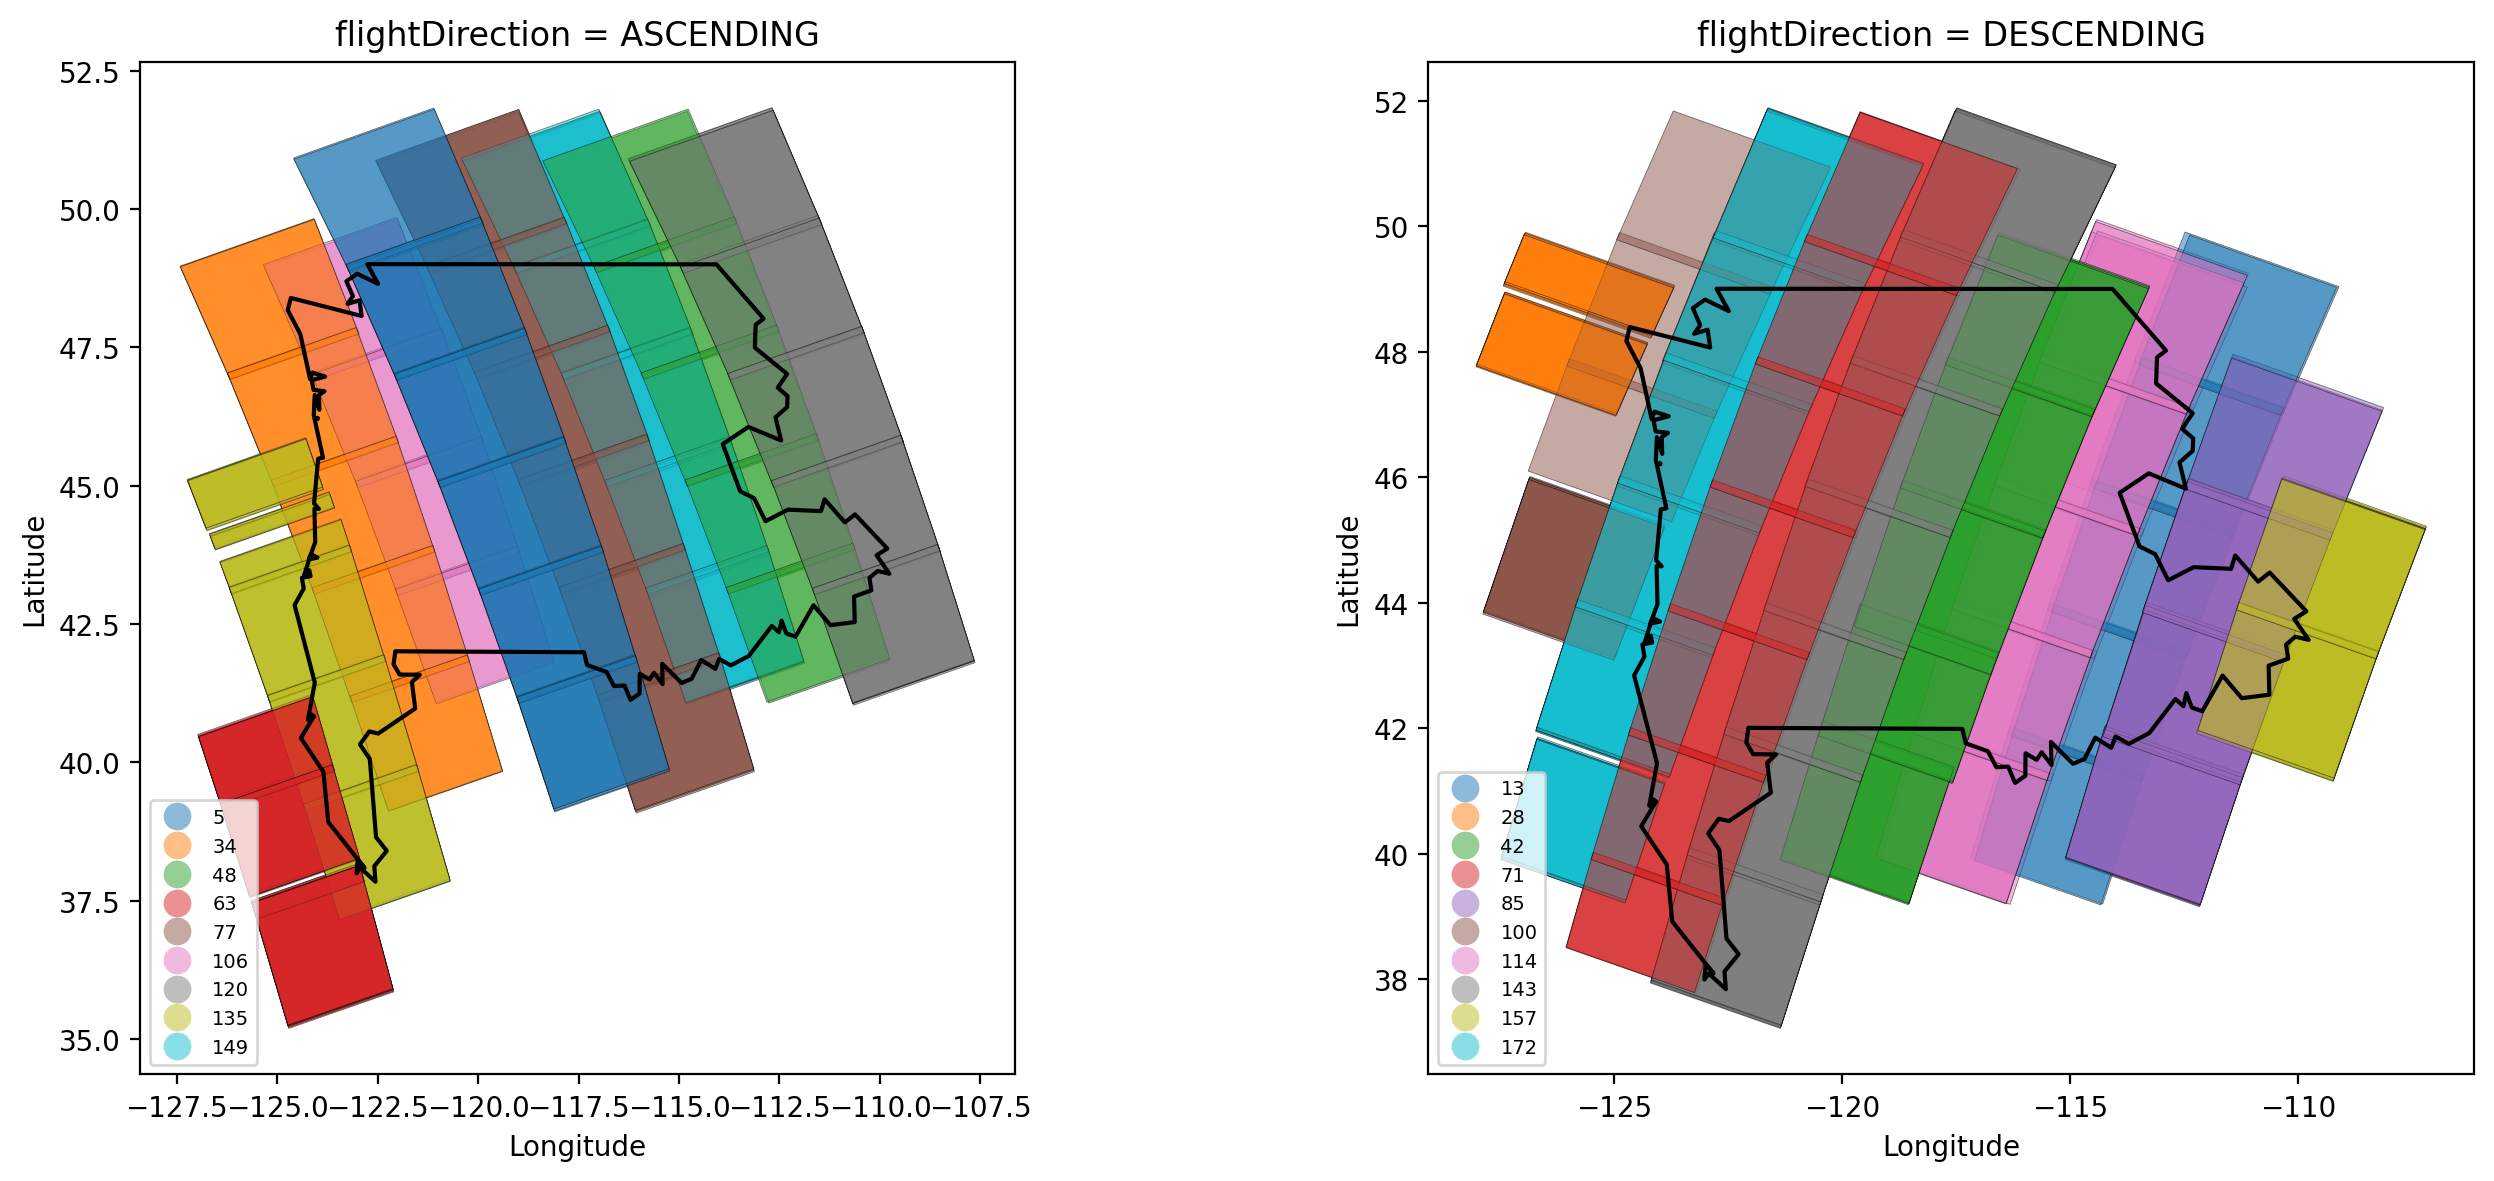

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, direction in zip(axes, ["ASCENDING", "DESCENDING"]):
    subset = gf.query(f'flightDirection == "{direction}"')
    subset.plot(ax=ax, column='pathNumber', categorical=True, legend=True,
                legend_kwds={'loc': 'lower left', 'fontsize': 7},
                alpha=0.5, edgecolor='k', linewidth=0.3)
    aoi.simplify(0.1).plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)
    ax.set_title(f'flightDirection = {direction}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('flight_direction.png', dpi=150, bbox_inches='tight')
plt.show()


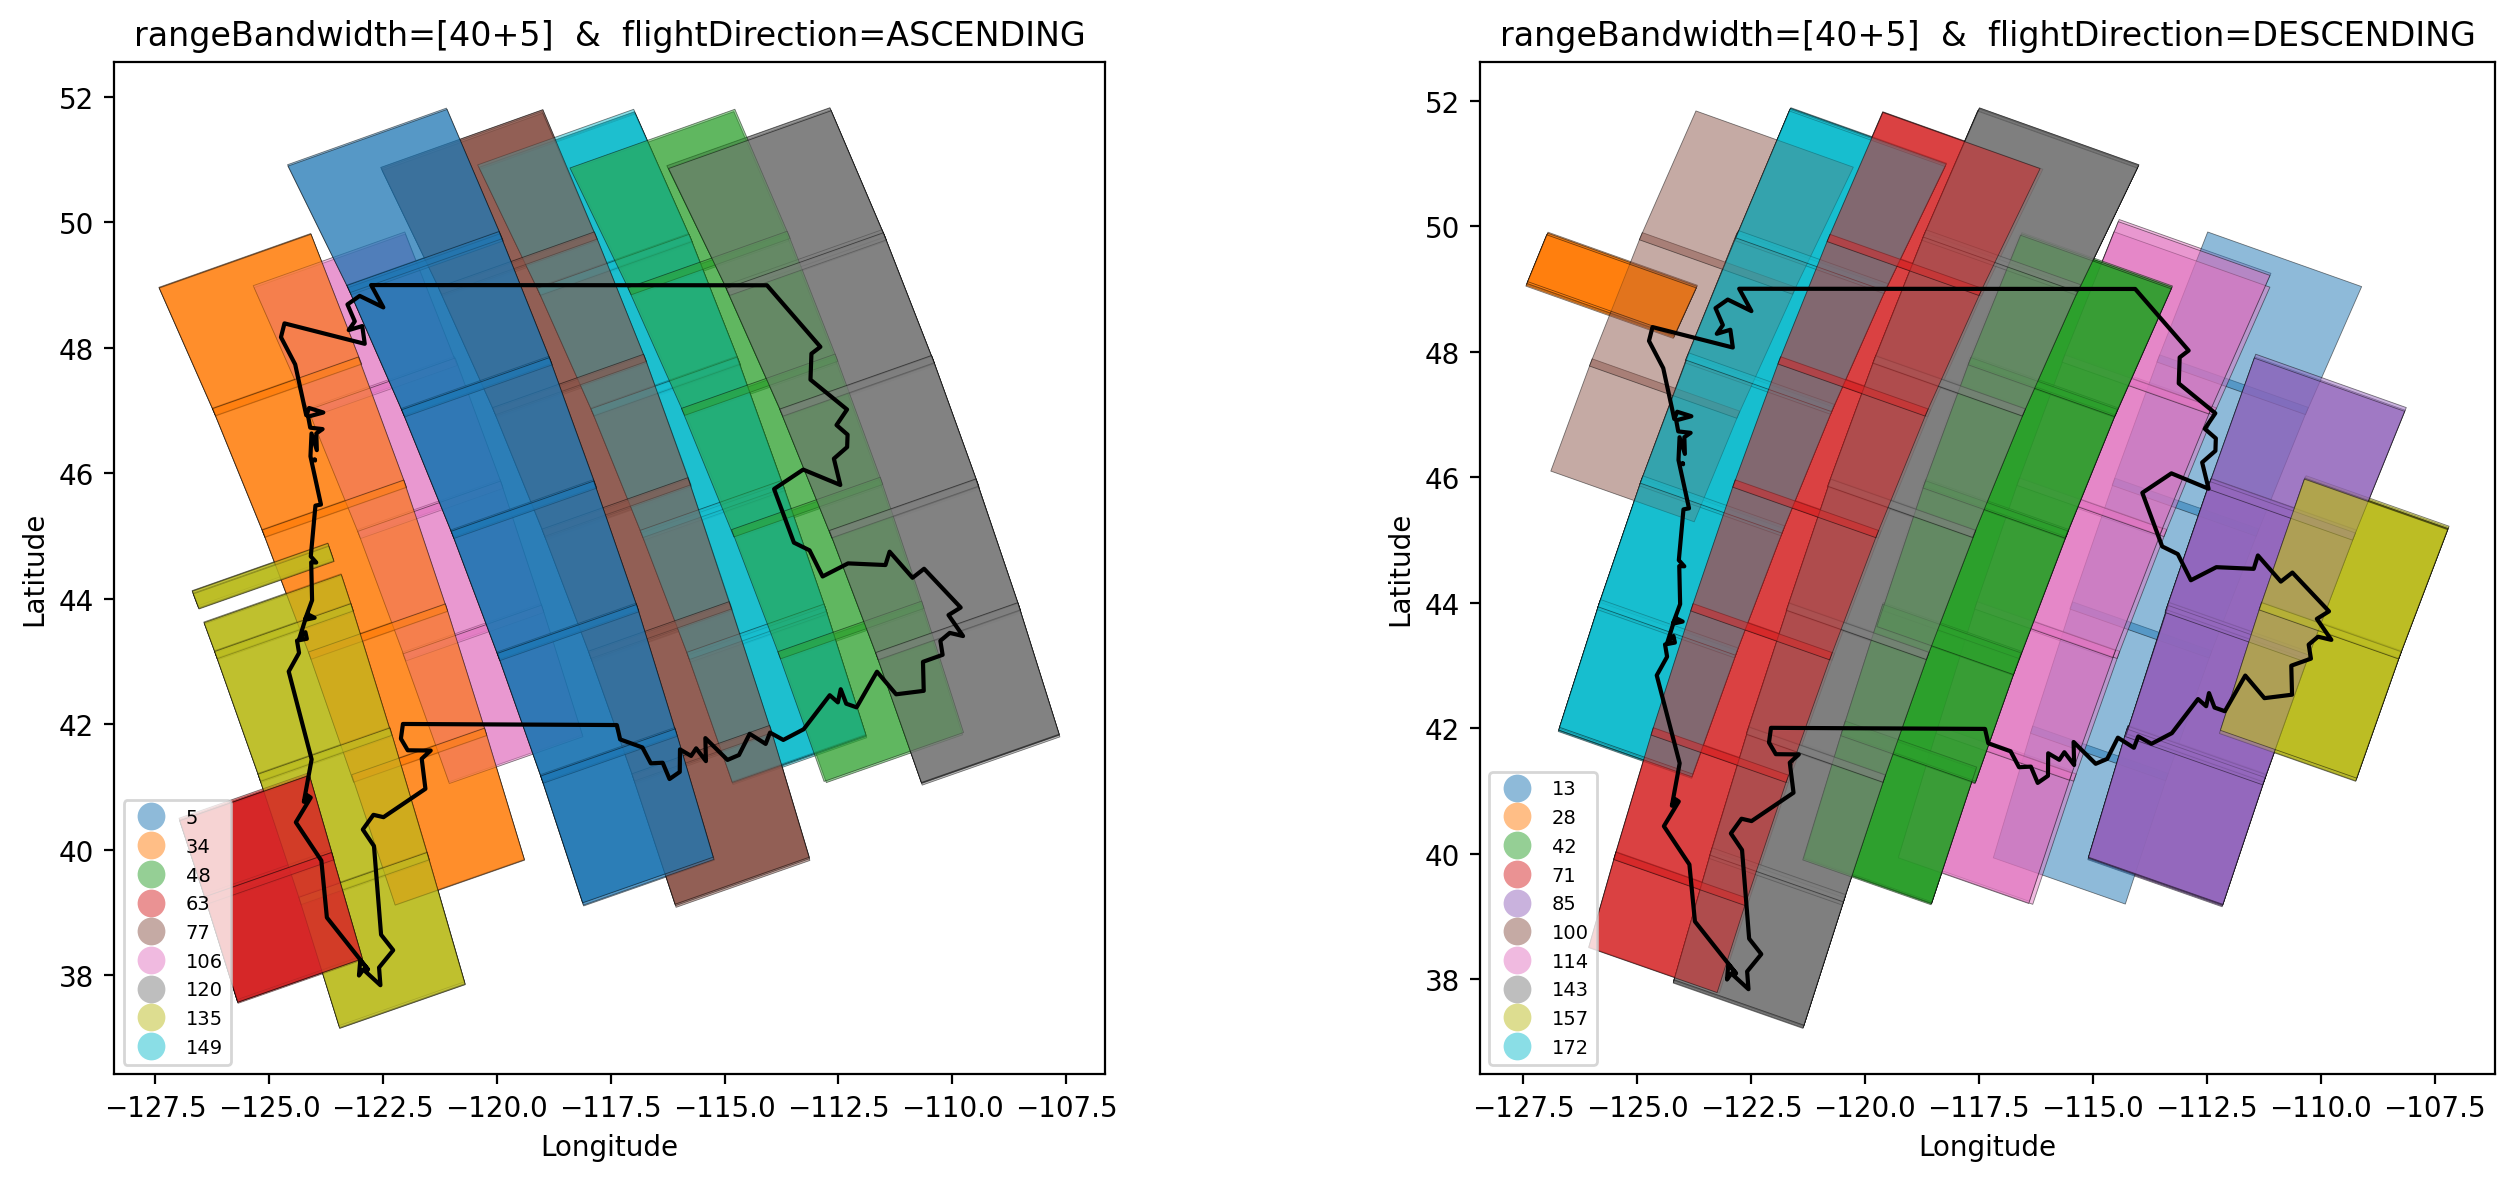

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gf_40p5 = gf[gf.rangeBandwidth.apply(lambda x: x == ['40+5'])]

for ax, direction in zip(axes, ["ASCENDING", "DESCENDING"]):
    subset = gf_40p5.query(f'flightDirection == "{direction}"')
    subset.plot(ax=ax, column='pathNumber', categorical=True, legend=True,
                legend_kwds={'loc': 'lower left', 'fontsize': 7},
                alpha=0.5, edgecolor='k', linewidth=0.3)
    aoi.simplify(0.1).plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)
    ax.set_title(f'rangeBandwidth=[40+5]  &  flightDirection={direction}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('flight_direction_40p5.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# Convert UTC time to US/Pacific time
utc_str = gf.iloc[0].startTime
utc_ts = pd.Timestamp(utc_str, tz='UTC')
pacific_ts = utc_ts.tz_convert('US/Pacific')
print(f"UTC:     {utc_ts}")
print(f"Pacific: {pacific_ts}")


UTC:     2026-01-20 02:21:43+00:00
Pacific: 2026-01-19 18:21:43-08:00


In [26]:
# Summarize acquisition times for this region for ascending and descending passes

# Convert startTime to UTC timestamps, then to US/Pacific
gf['startTime_utc'] = pd.to_datetime(gf['startTime'], utc=True)
gf['startTime_pacific'] = gf['startTime_utc'].dt.tz_convert('US/Pacific')

# Extract time-of-day as fractional hour for plotting
gf['time_of_day'] = gf['startTime_pacific'].dt.strftime('%H:%M:%S')
gf['hour_of_day_pacific'] = gf['startTime_pacific'].dt.hour + gf['startTime_pacific'].dt.minute / 60

# Group by flightDirection and summarize
summary = (
    gf.groupby('flightDirection')['startTime_pacific']
    .agg(
        count='count',
        date_range=lambda x: f"{x.dt.tz_convert('UTC').min().strftime('%Y-%m-%d')} – {x.dt.tz_convert('UTC').max().strftime('%Y-%m-%d')}",
        utc_time_range=lambda x: f"{x.dt.tz_convert('UTC').dt.strftime('%H:%M').min()} – {x.dt.tz_convert('UTC').dt.strftime('%H:%M').max()} UTC",
        pacific_time_range=lambda x: (
            f"{x.dt.strftime('%H:%M').min()} – {x.dt.strftime('%H:%M').max()} "
            f"({'PDT' if 'PDT' in x.dt.strftime('%Z').values else ''}"
            f"{'/' if 'PDT' in x.dt.strftime('%Z').values and 'PST' in x.dt.strftime('%Z').values else ''}"
            f"{'PST' if 'PST' in x.dt.strftime('%Z').values else ''})"
        ),
    )
)
print("Acquisition time summary (note: pacific_time_range spans PST & PDT due to DST):")
summary


Acquisition time summary (note: pacific_time_range spans PST & PDT due to DST):


,count,date_range,utc_time_range,pacific_time_range
flightDirection,,,,
ASCENDING,183,2025-10-17 – 2026-01-19,12:20 – 13:26 UTC,04:20 – 06:26 (PDT/PST)
DESCENDING,242,2025-10-22 – 2026-01-20,02:21 – 03:35 UTC,18:21 – 20:35 (PDT/PST)


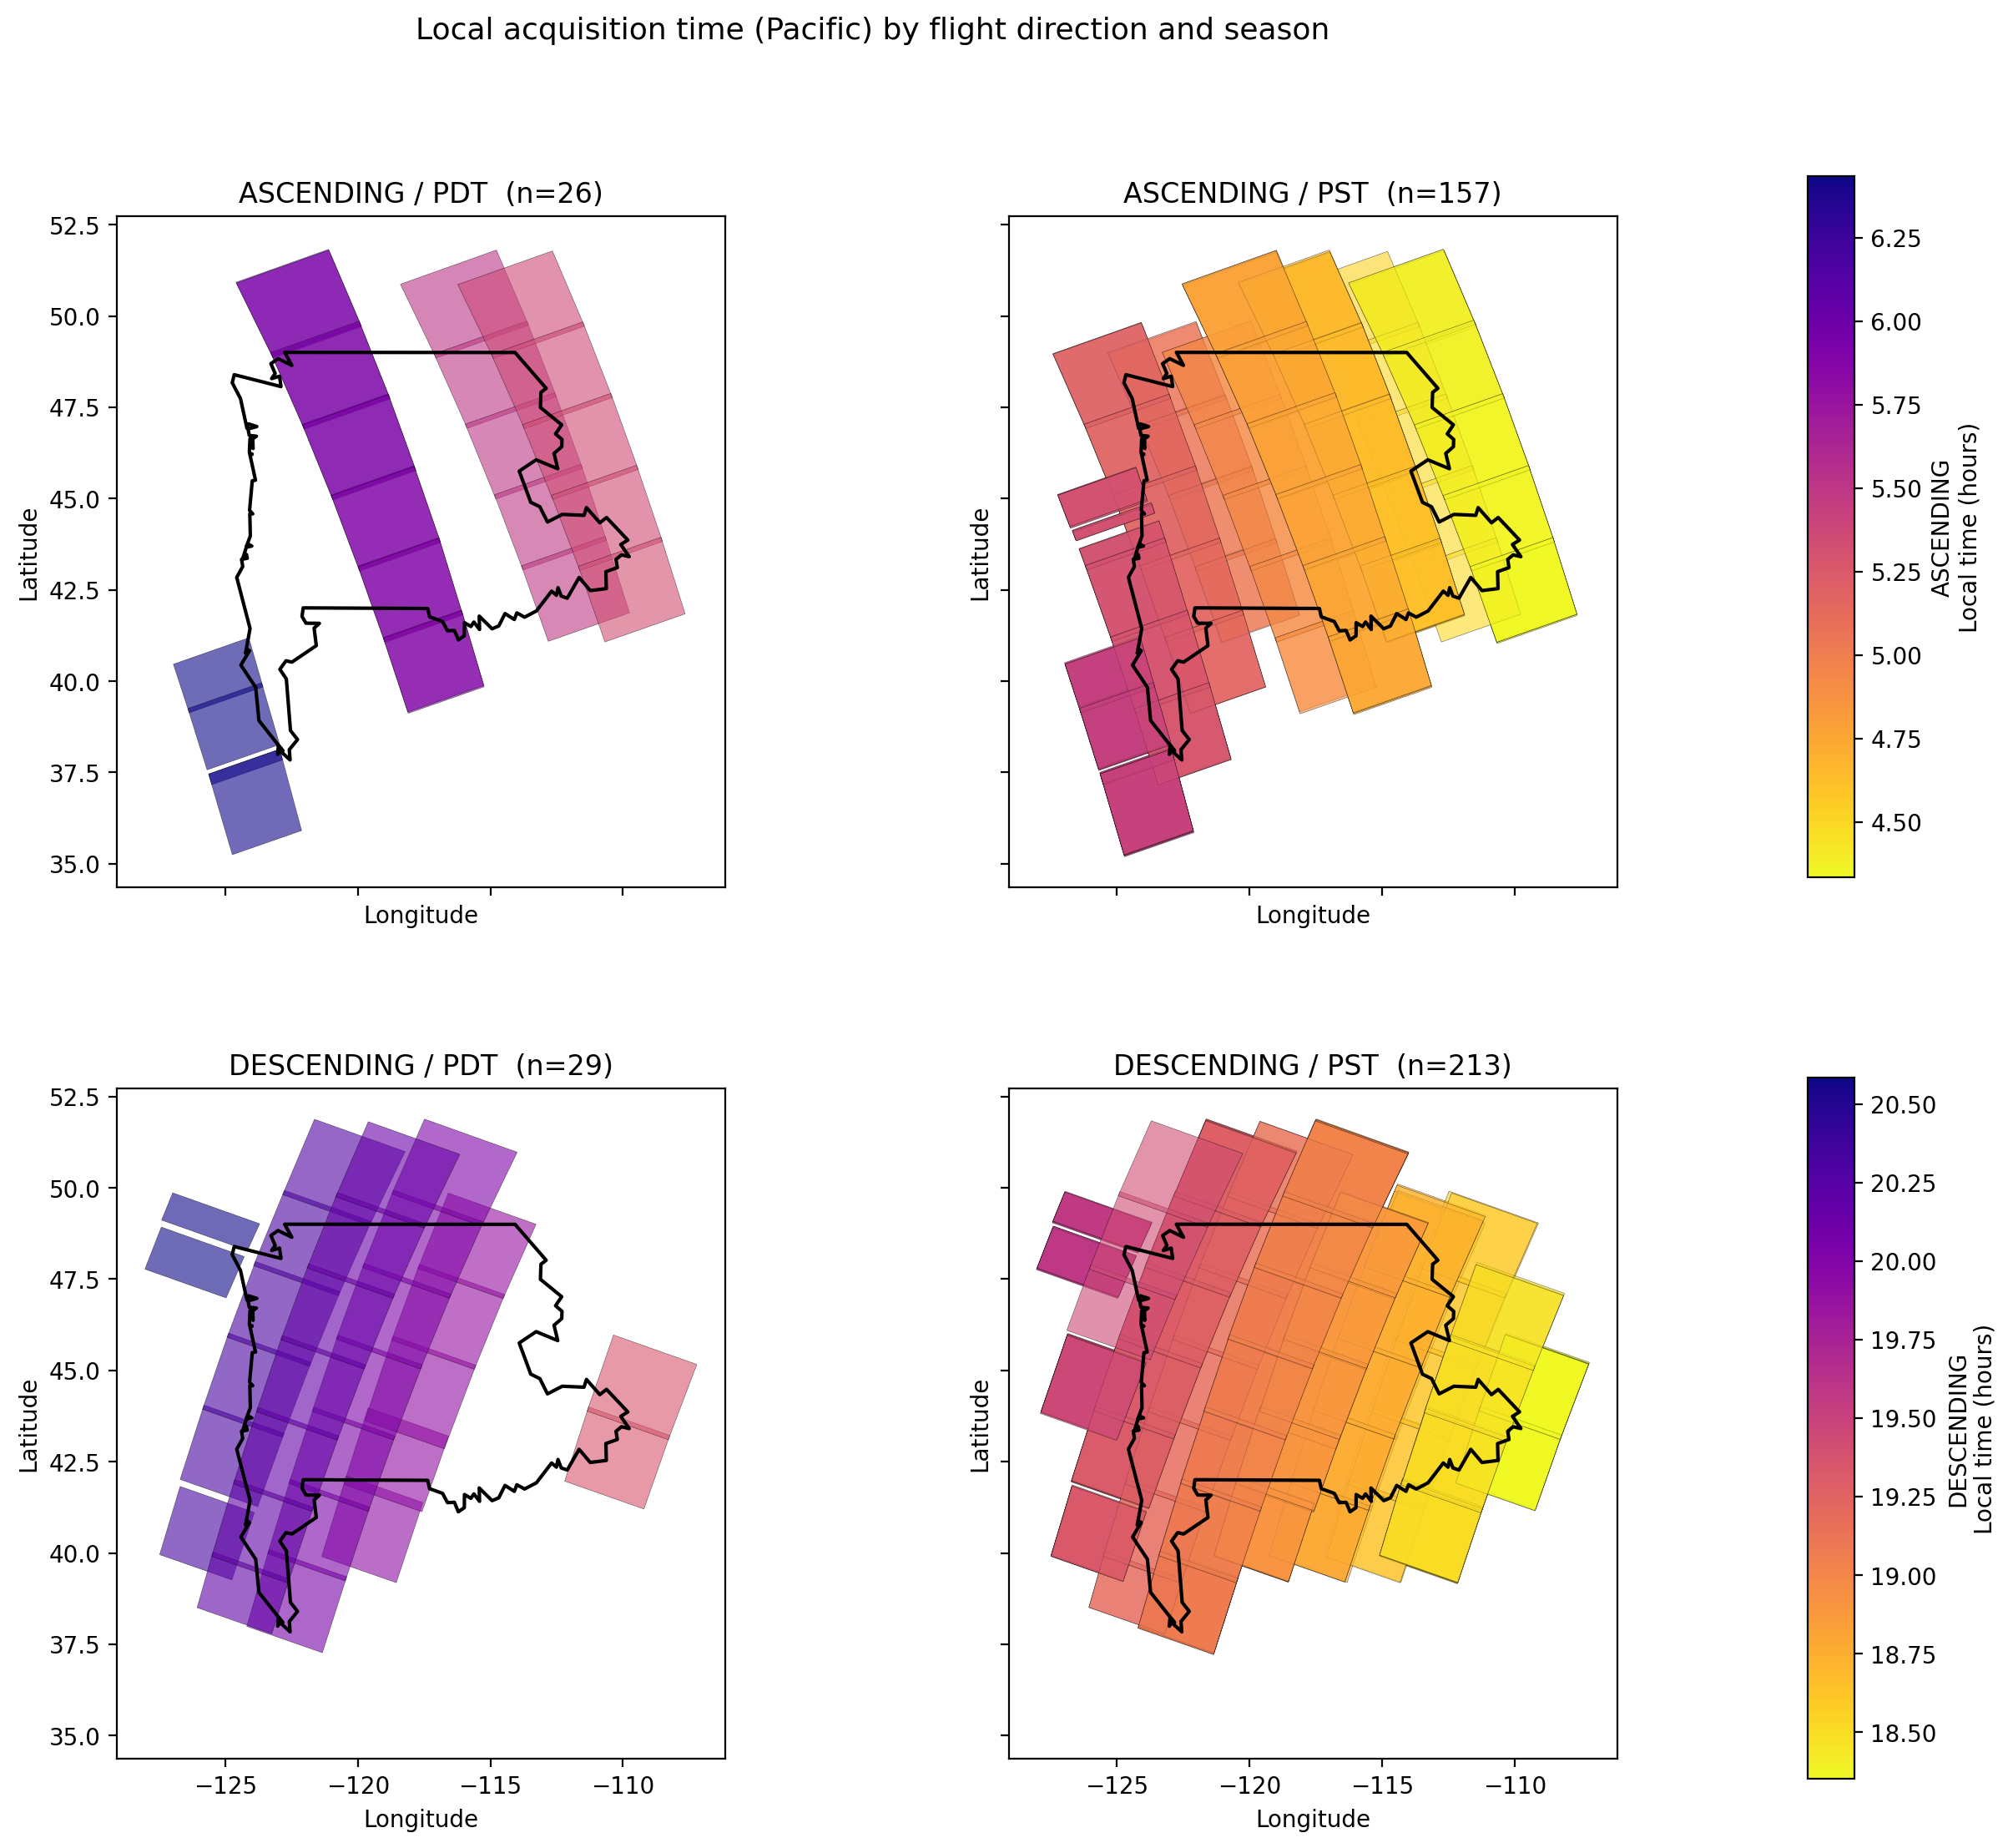

In [27]:
# Map showing variation in local acquisition time (hour of day) across the domain
# Separate panels for PDT (summer) and PST (winter)
# All subplots share the same x/y limits; each row has its own colorbar

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Tag each row with its timezone abbreviation
gf['tz_abbr'] = gf['startTime_pacific'].dt.strftime('%Z')  # 'PDT' or 'PST'

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
# Leave space on the right for two colorbars
fig.subplots_adjust(right=0.87, hspace=0.3, wspace=0.05)

cbar_axes = [
    fig.add_axes([0.90, 0.55, 0.02, 0.35]),  # colorbar for row 0 (ASCENDING)
    fig.add_axes([0.90, 0.10, 0.02, 0.35]),  # colorbar for row 1 (DESCENDING)
]

for row, direction in enumerate(["ASCENDING", "DESCENDING"]):
    # Shared vmin/vmax across both PDT and PST panels for this row
    row_subset = gf.query(f'flightDirection == "{direction}"')
    vmin = row_subset['hour_of_day_pacific'].min()
    vmax = row_subset['hour_of_day_pacific'].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.plasma_r

    for col, tz in enumerate(["PDT", "PST"]):
        ax = axes[row, col]
        subset = gf.query(f'flightDirection == "{direction}" and tz_abbr == "{tz}"').copy()

        if subset.empty:
            ax.set_title(f'{direction} / {tz}\n(no data)')
            ax.set_visible(False)
            continue

        subset.plot(
            ax=ax,
            column='hour_of_day_pacific',
            cmap=cmap,
            norm=norm,

            alpha=0.6,
            edgecolor='k',
            linewidth=0.2,
            legend=False,
        )
        aoi.simplify(0.1).plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)
        ax.set_title(f'{direction} / {tz}  (n={len(subset)})')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

    # Dedicated colorbar axis for this row
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_axes[row], orientation='vertical')
    cbar.set_label(f'{direction}\nLocal time (hours)', fontsize=10)

plt.suptitle('Local acquisition time (Pacific) by flight direction and season', fontsize=13)
plt.savefig('acquisition_time_map_pdt_pst.png', dpi=150, bbox_inches='tight')
plt.show()


Caption: Local time of acquisition of NISAR data in Cascadia. UTC acquisition times across the domain range from 12:20 – 13:26 UTC for Ascending acquisitions (04:20 PDT – 06:26 PST)  and 02:21 – 03:35 UTC for Descending acquisitions (18:21 PDT – 20:35 PST). 

NOTE: Daylight savings for US/Pacific is PDT (UTC−7): second Sunday of March → first Sunday of November, otherwise PST (UTC−8). 

NOTE: I've always used the mnemonic "Ascending = Afternoon" to remember the local time of acquisition for ascending vs. descending passes but I guess that depends on look direction (applies to Sentinel-1 / right-looking sensors. 

## Coverage maps

Create a simple 'count' of coverage across the domain using xvec: https://xvec.readthedocs.io/en/stable/zonal_stats.html

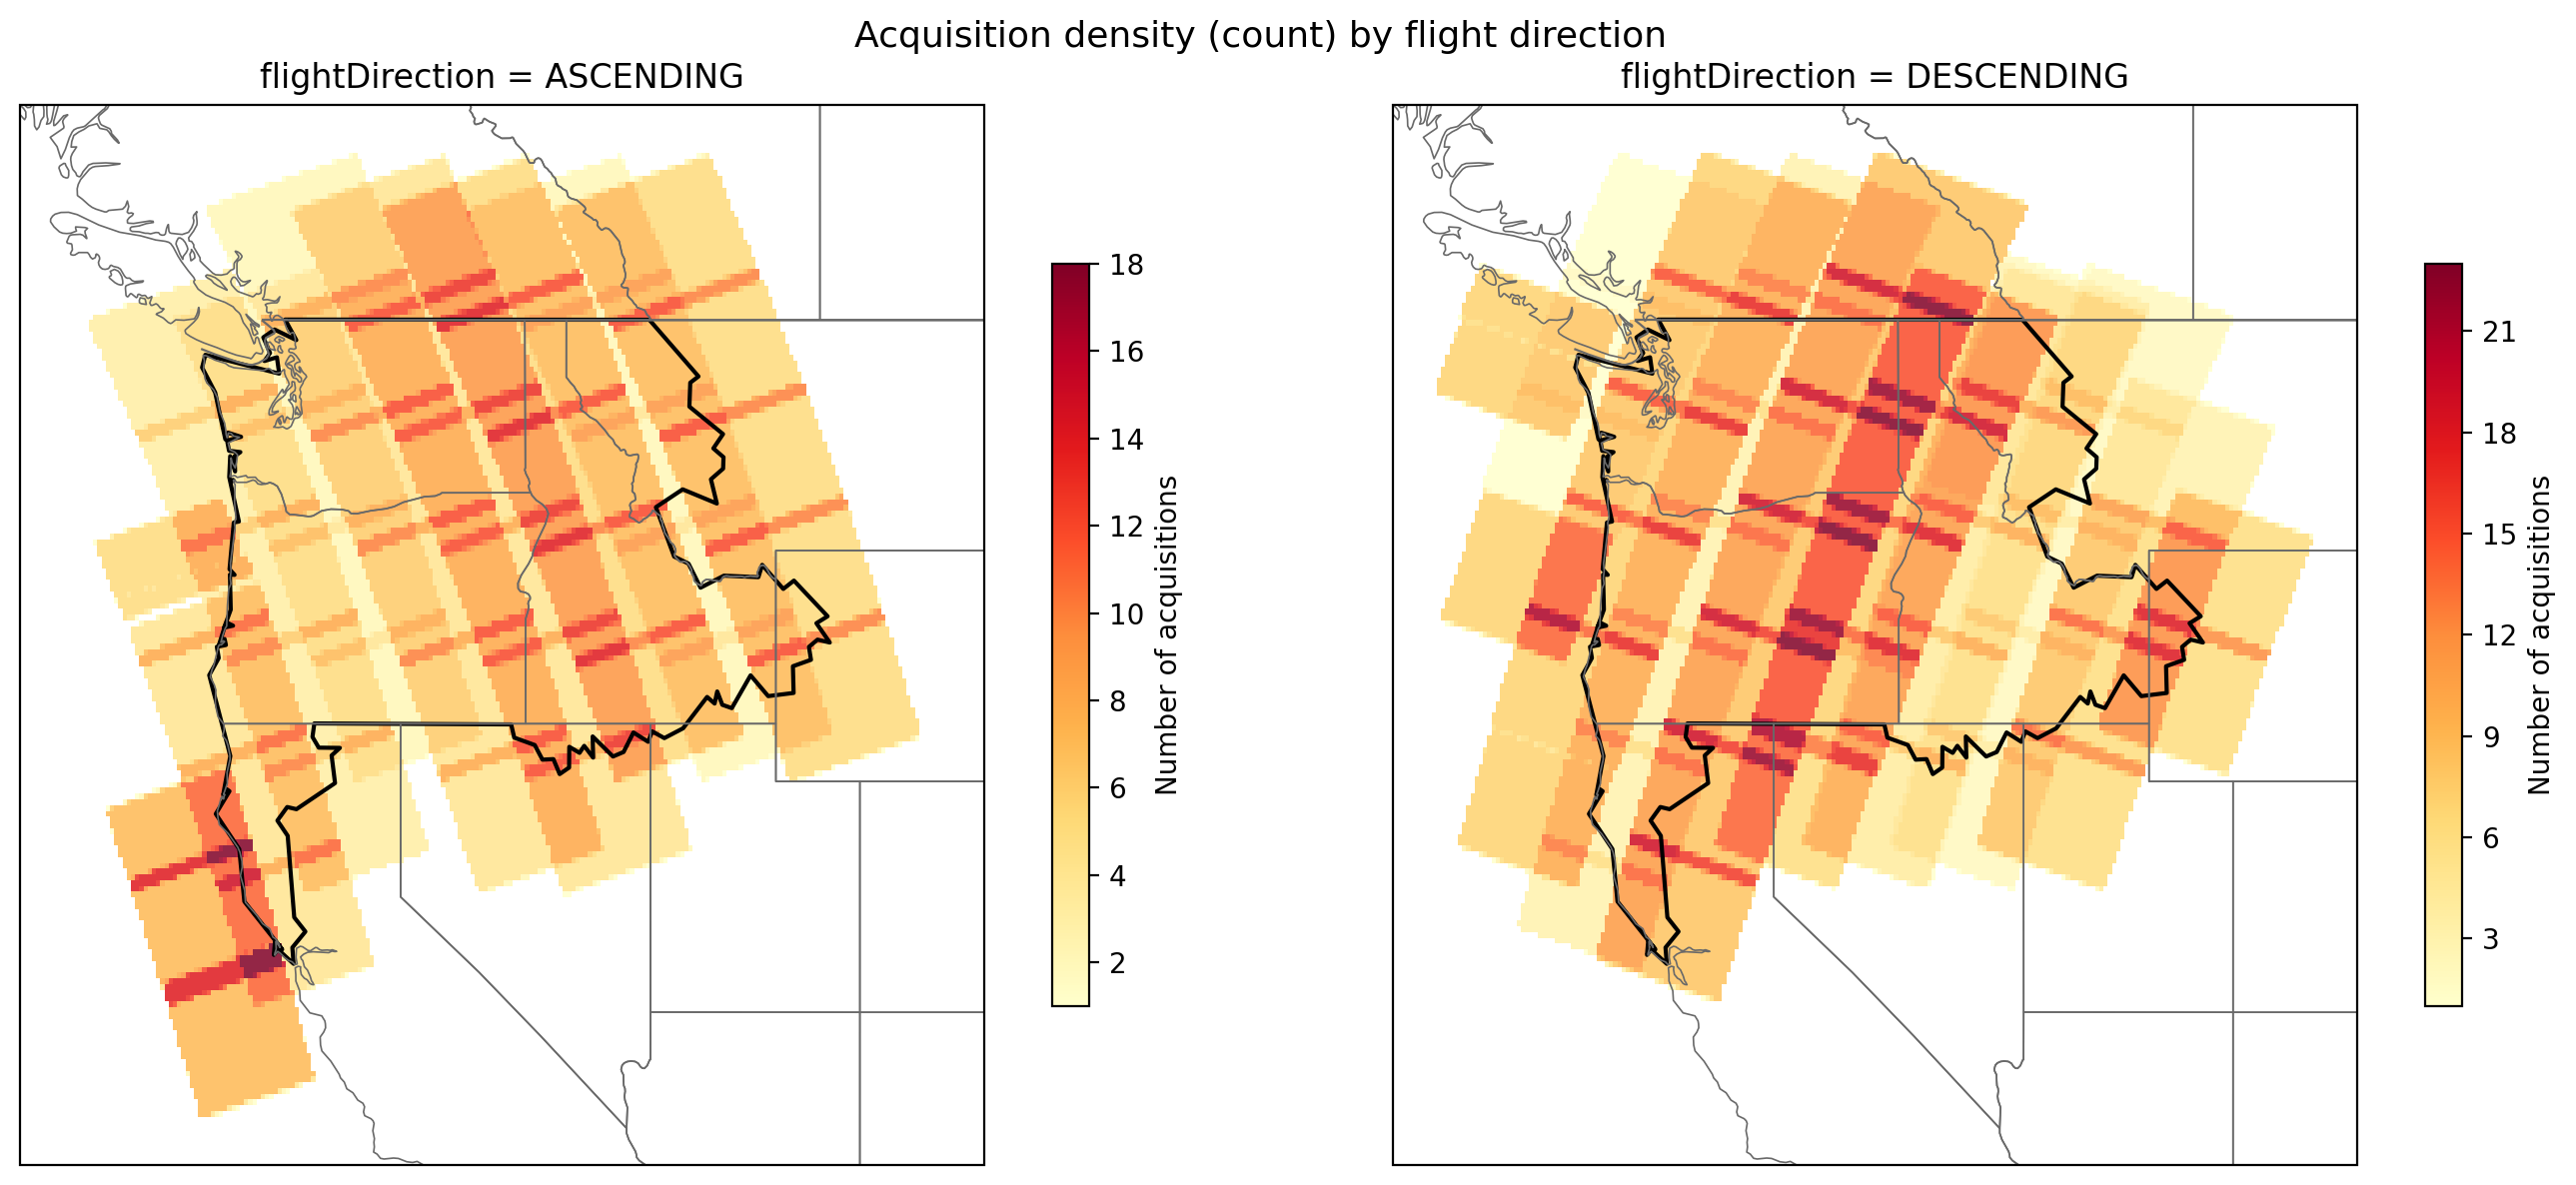

In [28]:
import xvec
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Build a regular lat/lon grid over the domain
res = 0.1  # degrees
xmin, ymin, xmax, ymax = gf.total_bounds
x_coords = np.arange(xmin, xmax, res)
y_coords = np.arange(ymin, ymax, res)

# Create grid cell polygons as a GeoDataFrame
from shapely.geometry import box

grid_cells = [box(x, y, x + res, y + res)
              for y in y_coords for x in x_coords]
grid = gpd.GeoDataFrame(geometry=grid_cells, crs='EPSG:4326')

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={'projection': proj},
                         sharex=True, sharey=True)

for ax, direction in zip(axes, ["ASCENDING", "DESCENDING"]):
    subset = gf.query(f'flightDirection == "{direction}"')

    # Count how many footprints intersect each grid cell
    counts = grid.geometry.apply(
        lambda cell: subset.intersects(cell).sum()
    )
    grid['count'] = counts

    # Mask cells with zero coverage
    grid_nonzero = grid[grid['count'] > 0].copy()

    vmax = int(grid_nonzero['count'].max())
    im = grid_nonzero.plot(
        ax=ax,
        column='count',
        cmap='YlOrRd',
        vmin=1,
        vmax=vmax,
        legend=True,
        legend_kwds={
            'label': 'Number of acquisitions',
            'shrink': 0.7,
            'ticks': mticker.MaxNLocator(integer=True),
        },
        alpha=0.85,
        edgecolor='none',
        transform=proj,
    )

    # State/province boundaries
    ax.add_feature(cfeature.STATES, linewidth=0.6, edgecolor='dimgray', zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='dimgray', zorder=2)

    # AOI outline
    aoi.simplify(0.1).plot(ax=ax, color='none', edgecolor='black', linewidth=1.5, transform=proj)

    ax.set_title(f'flightDirection = {direction}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Acquisition density (count) by flight direction', fontsize=13)
plt.tight_layout()
plt.savefig('acquisition_density.png', dpi=150, bbox_inches='tight')
plt.show()
